<a href="https://colab.research.google.com/github/phani-x507/DeepLearning/blob/main/01_Pytorch_workfow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PyTorch Workflow
 Lets Explore an example PyTorch end-to-end workflow


*   Data(Prepare and Load)
*   Build Model
*   Fitting the model to data (training)
*   Making predictions and evaluating the model (inference)
*   Saving and loading a model
*   Putting it all together





In [68]:
import torch
from torch import nn #Contains building blocks of neural networks
import matplotlib.pyplot as plt

#check PyTorch version
torch.__version__

'2.10.0+cpu'

# 1. Data
  - Data can be almost Anything
  - Our part is convert it into Numerical Encoding

## Lets Start with Linear Regression
 - formula `fw,b = w.x+b`


In [69]:
w = 0.7
b = 0.3

X = torch.arange(0,1,0.02).unsqueeze(dim=1) # Creates tensor and adds extra dimension 1d->2d
Y = w*X+b

X[:10] , Y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [70]:
X.shape,Y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

### Splitting data into training and test sets
  - One of the most important concepts in machine learning

In [71]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split] , Y[:train_split]
X_test , Y_test = X[train_split:],Y[train_split:]

len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

In [72]:
def plot_predictions(train_data = X_train,
                     train_labels = Y_train,
                     test_data = X_test,
                     test_labels = Y_test,
                     predictions = None):

  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b',s=20)
  plt.scatter(test_data , test_labels , c='g',s=20)
  if predictions is not None:
    plt.scatter(test_data, predictions)
  plt.legend()
  plt.plot()

/tmp/ipykernel_2766/2771110265.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


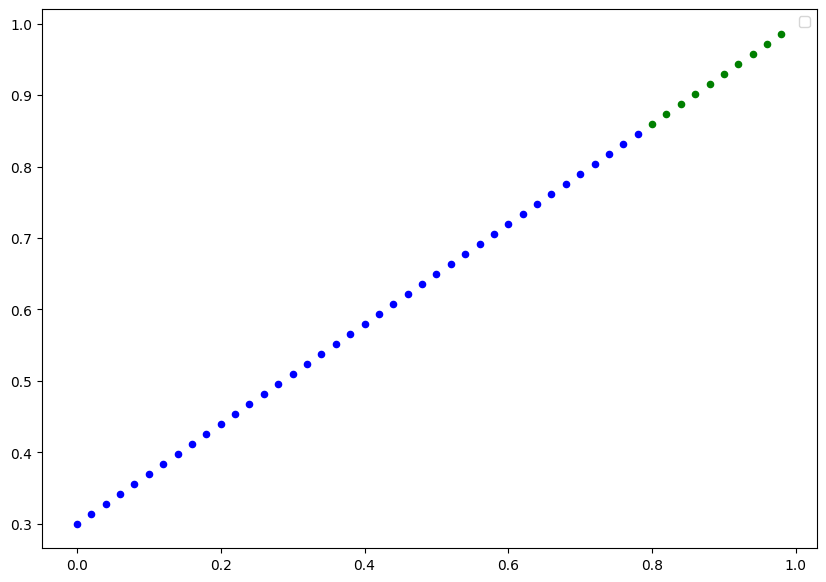

In [73]:
plot_predictions()

# Build Model
 - Build Linear Regression Model

In [74]:
from numpy import dtype
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Model takes these parameters and Learn in the background
    self.weights = nn.Parameter(torch.randn(1,
                                requires_grad=True,
                                dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,dtype=torch.float))

  # override forward method to include computation like linear regression
  # If we subclass nn.Module, we need to override this method
  def forward(self,x:torch.Tensor) -> torch.Tensor: #->torch.Tensor: means output should be tensor
    return self.weights * x + self.bias



### Pytorch model building essentials
 - `torch.nn` -> contains the building blocks of computational graphs(a neural network can be considered as computational graph).
 - `torch.nn.Parameter` -> what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us.
 - `torch.nn.Module` -> This is the base class for neural network modules, if you subclass it you need to override the `forward()` method.
 - `torch.optim` -> this where the PyTorch optimizers live, they will help with gradient descent.

 - See PyTorch cheatsheet for Reference.


In [75]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model
lin_reg = LinearRegressionModel()
list(lin_reg.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [76]:
#List named parameters
lin_reg.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [77]:
# predicting with the method below disables all important methods like gradient Descent and other optimizations reducing the overhead.
# we don't use this regularly.
# Check in google: Pytorch inference mode twitter
with torch.inference_mode():
  y_preds = lin_reg(X_test)
y_preds

# This does the same as above but less recommended
# with torch.no_grad():
#   y_preds = lin_reg(X_test)
# y_preds
# not same but similar

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

/tmp/ipykernel_2766/2771110265.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


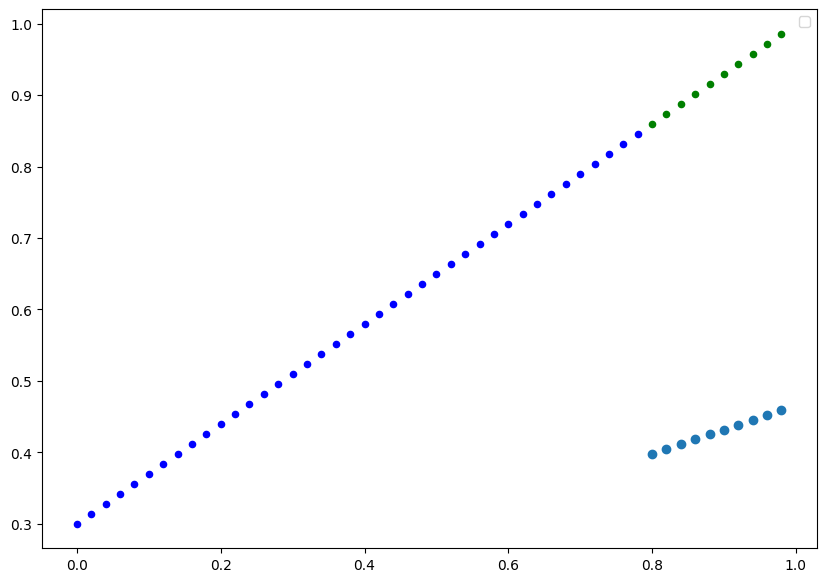

In [78]:
plot_predictions(predictions=y_preds)

## Loss Function
 - A function to measue how wrong your's models predictions to the ideal outputs
 - Lower is better
## Optimzer
 - Takes into account the loss of a model and adjusts the parameters(weights and bias) to get ideal predictions.  

** Using these two can be habitated by experience **

In [79]:
# Loss function (There are multiple loss functions refer to PyTorch website)
# L1Loss is Basically Mean Absolute Error(MAE) -> difference(y_pred[0] - y_test[0])
loss_fn = nn.L1Loss()

# Optimiser - we are using Stocastic Gradient Descent (Most Popular) and Other algorithms also available
# Suchas Adam
optimizer = torch.optim.SGD(params=lin_reg.parameters(), lr=0.01 ) #Learning Rate is the most important Hyper Paramter


# Building a Training Loop and Testing Loop in PyTorch
0. Loop through the data
1. Forward Pass ( this involves data moving through our model's forward()) to make predictions on data functions also called forward propagation
2. Calculate the loss (Compare forward pass predictions to ground truth labels).
3. Optimize zero grad.
4. Loss Backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss **(Backpropagation)**
5. Optimizer Step - use the optimizer to adjust our model's parameters to try and improve the loss.**(Gradient Descent)**

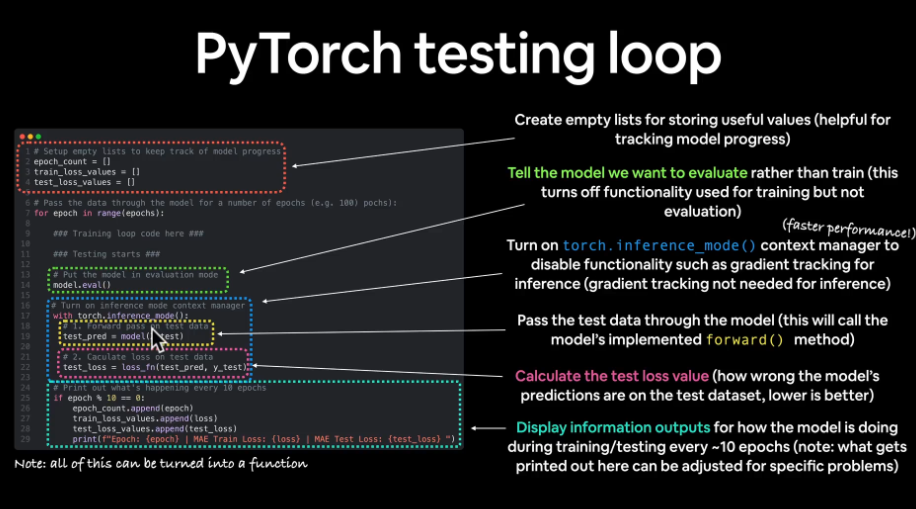

In [92]:
epochs = 170
epoch_count = []
train_loss_values = []
test_loss_values = []
for epoch in range(epochs):
  #Training
  lin_reg.train().



  #Fitting
  y_pred = lin_reg(X_train)

  #Calculate the loss
  loss = loss_fn(y_pred,Y_train)
  print("Loss : ", loss)

  #Optimizer
  optimizer.zero_grad() #Make the gradients to zero for every loop

  #Back Propagation
  loss.backward()

  #Step the optimizer - used to step down in gradient descent
  optimizer.step()

  #For Testing
  lin_reg.eval()
  with torch.inference_mode():

    #Do the forward Pass
    test_pred = lin_reg(X_test)

    #Calculate the Loss
    test_Loss = loss_fn(test_pred, Y_test)
    #Print what happening for every 10 epochs
  if epoch %10 ==0:
    epoch_count.append(epoch)
    train_loss_values.append(loss)
    test_loss_values.append(test_Loss)
    print(f"Epoch : {epoch} | Loss : {loss} | Test Loss : {test_Loss}")

  #Printout the model state_dict
  print(lin_reg.state_dict())

SyntaxError: invalid syntax (2747069152.py, line 7)

In [82]:
with torch.inference_mode():
  y_pred_new = lin_reg(X_test)

/tmp/ipykernel_2766/2771110265.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


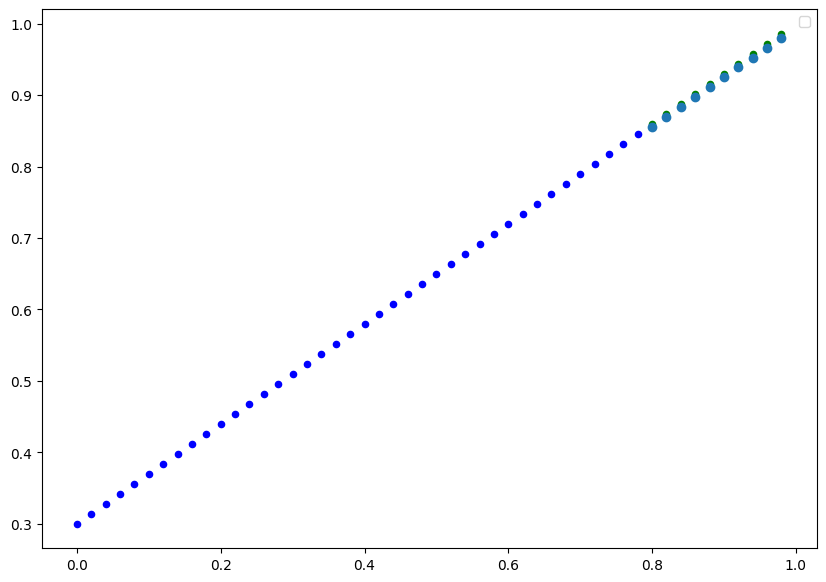

In [83]:
plot_predictions(predictions=y_pred_new)

In [88]:
import numpy as np

epoch_count,np.array(torch.tensor(train_loss_values).numpy()),test_loss_values

/tmp/ipykernel_2766/3829309207.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  epoch_count,np.array(torch.tensor(train_loss_values).numpy()),test_loss_values


([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160],
 array([0.30136034, 0.18615034, 0.08227583, 0.05181945, 0.04503796,
        0.04132963, 0.03785244, 0.03441364, 0.03097964, 0.02754883,
        0.02411001, 0.02067771, 0.0172452 , 0.0138064 , 0.01037578,
        0.00694158, 0.00350277], dtype=float32),
 [tensor(0.4676),
  tensor(0.3329),
  tensor(0.2070),
  tensor(0.1402),
  tensor(0.1118),
  tensor(0.0981),
  tensor(0.0878),
  tensor(0.0795),
  tensor(0.0719),
  tensor(0.0636),
  tensor(0.0554),
  tensor(0.0478),
  tensor(0.0395),
  tensor(0.0312),
  tensor(0.0236),
  tensor(0.0154),
  tensor(0.0071)])

/tmp/ipykernel_2766/717176174.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


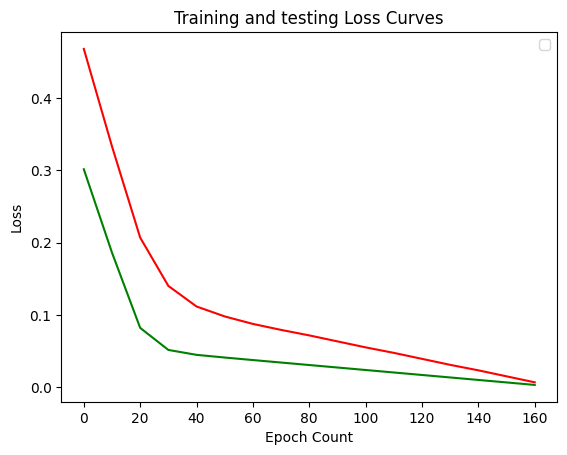

In [91]:
plt.plot(epoch_count,np.array(torch.tensor(train_loss_values).numpy()),c='g')
plt.plot(epoch_count,np.array(torch.tensor(test_loss_values).numpy()),c='r')
plt.title("Training and testing Loss Curves")
plt.xlabel("Epoch Count")
plt.ylabel('Loss')
plt.legend();